# Assessment 11: Market Basket Analysis

**Created by:**

* Benedict S. Caliba
* Marcelo B. Cosme
* Aaron Kane M. Dungca

**Date Submitted:** May 9, 2026

In [9]:
# Install mlxtend if not yet installed
# !pip install mlxtend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print("All libraries loaded successfully!")

All libraries loaded successfully!


# Task 1 

In [2]:
# 1. Load Data and Analyze
df = pd.read_csv("sen.csv")
print("File Read Successfully!")
print("Data Shape")
print(df.shape)
print("Columns")      
print(df.columns)    

File Read Successfully!
Data Shape
(105971, 71)
Columns
Index(['Unnamed: 0', 'region', 'province', 'city', 'brgy', 'precinct',
       'total_votes', 'sen_1_afuang', 'sen_2_albani', 'sen_3_arranza',
       'sen_4_baguilat', 'sen_5_bailen', 'sen_6_balita', 'sen_7_barbo',
       'sen_8_bautista', 'sen_9_belgica', 'sen_10_bello', 'sen_11_binay',
       'sen_12_cabonegro', 'sen_13_castriciones', 'sen_14_cayetano',
       'sen_15_chavez', 'sen_16_colmenares', 'sen_17_d_angelo',
       'sen_18_de_lima', 'sen_19_del_rosario', 'sen_20_diaz', 'sen_21_diokno',
       'sen_22_ejercito', 'sen_23_eleazar', 'sen_24_ereño', 'sen_25_escudero',
       'sen_26_espiritu', 'sen_27_estrada', 'sen_28_falcone', 'sen_29_gadon',
       'sen_30_gatchalian', 'sen_31_gordon', 'sen_32_gutoc', 'sen_33_honasan',
       'sen_34_hontiveros', 'sen_35_javellana', 'sen_36_kiram', 'sen_37_labog',
       'sen_38_lacson', 'sen_39_langit', 'sen_40_legarda', 'sen_41_lim',
       'sen_42_mallillin', 'sen_43_marcoleta', 'sen_44_

In [3]:
# 2. Group & Sum
sen_cols = [c for c in df.columns if c.startswith('sen_')]
provincial_sums = df.groupby('province')[sen_cols].sum()

# 3. Get Top 8
transactions = []
for index, row in provincial_sums.iterrows():
    top_8 = row.nlargest(8).index.str.replace('sen_', '').tolist()
    transactions.append(top_8)

print("Succesful!!")

Succesful!!


In [4]:
# Create an empty list to hold all transactions
transactions = []

# Loop through each row of the grouped dataframe
for index, row in provincial_sums.iterrows():
    # 1. Get the top 8 senators for this specific province
    # 2. Extract their names (the column index)
    # 3. Remove 'sen_' prefix and convert to a list
    top_8 = row.nlargest(8).index.str.replace('sen_', '').tolist()
    
    # Add this province's top 8 to our master list
    transactions.append(top_8)

print(transactions)
print(f"Total Transactions: {len(transactions)}")
print("Printing Success")

[['49_padilla', '27_estrada', '62_villar', '11_binay', '59_tulfo', '22_ejercito', '40_legarda', '30_gatchalian'], ['49_padilla', '64_zubiri', '40_legarda', '62_villar', '30_gatchalian', '61_villanueva', '57_teodoro', '59_tulfo'], ['49_padilla', '64_zubiri', '40_legarda', '14_cayetano', '62_villar', '30_gatchalian', '22_ejercito', '59_tulfo'], ['40_legarda', '59_tulfo', '34_hontiveros', '61_villanueva', '25_escudero', '49_padilla', '30_gatchalian', '62_villar'], ['25_escudero', '34_hontiveros', '59_tulfo', '58_trillanes', '18_de_lima', '40_legarda', '14_cayetano', '21_diokno'], ['40_legarda', '49_padilla', '25_escudero', '62_villar', '59_tulfo', '64_zubiri', '8_bautista', '57_teodoro'], ['40_legarda', '59_tulfo', '49_padilla', '25_escudero', '30_gatchalian', '14_cayetano', '34_hontiveros', '61_villanueva'], ['49_padilla', '59_tulfo', '40_legarda', '62_villar', '11_binay', '27_estrada', '22_ejercito', '14_cayetano'], ['49_padilla', '40_legarda', '62_villar', '29_gadon', '54_roque', '8_ba

# Task 2

In [5]:
# 1. One-Hot Encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# 2. Run Apriori
frequent_itemsets = apriori(df_encoded, min_support=0.3, use_colnames=True)
print(f"Number of frequent itemsets found: {len(frequent_itemsets)}")

# 3. Add itemset_size and filter
frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

# Display 2-itemsets and 3-itemsets
print(frequent_itemsets[frequent_itemsets['itemset_size'] == 2])
print(frequent_itemsets[frequent_itemsets['itemset_size'] == 3])

Number of frequent itemsets found: 191
     support                                   itemsets  itemset_size
10  0.411111      frozenset({14_cayetano, 25_escudero})             2
11  0.577778    frozenset({30_gatchalian, 14_cayetano})             2
12  0.711111       frozenset({40_legarda, 14_cayetano})             2
13  0.666667       frozenset({49_padilla, 14_cayetano})             2
14  0.677778         frozenset({14_cayetano, 59_tulfo})             2
15  0.311111    frozenset({61_villanueva, 14_cayetano})             2
16  0.522222        frozenset({14_cayetano, 62_villar})             2
17  0.344444        frozenset({14_cayetano, 64_zubiri})             2
18  0.466667    frozenset({30_gatchalian, 25_escudero})             2
19  0.555556       frozenset({40_legarda, 25_escudero})             2
20  0.488889       frozenset({49_padilla, 25_escudero})             2
21  0.555556         frozenset({25_escudero, 59_tulfo})             2
22  0.377778    frozenset({61_villanueva, 25_escude

#### Number 35. 40_Legarda and 62_Villar seems to have the highest number of support followed by Number 34. with 40_Legarda and 59_Tulfo
* This basically means over 93% of the provinces voted for Number 35, and over 91% voted for 34

# Task 3

In [6]:
# Generate rules
# num_itemsets is required in newer versions of mlxtend
rules = association_rules(frequent_itemsets, 
                          metric="confidence", 
                          min_threshold=0.7, 
                          num_itemsets=len(frequent_itemsets))

# Select and sort columns
rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules_display = rules_display.sort_values(by='lift', ascending=False)

# Filter the rules
filtered_rules = rules_display[(rules_display['lift'] > 1.2) & (rules_display['confidence'] > 0.75)]

print(f"Number of rules remaining: {len(filtered_rules)}")
print(filtered_rules.head())

Number of rules remaining: 82
                                           antecedents  \
945  frozenset({61_villanueva, 40_legarda, 49_padil...   
961  frozenset({61_villanueva, 40_legarda, 49_padil...   
738  frozenset({61_villanueva, 40_legarda, 49_padil...   
943  frozenset({30_gatchalian, 61_villanueva, 40_le...   
959  frozenset({30_gatchalian, 61_villanueva, 40_le...   

                                           consequents   support  confidence  \
945            frozenset({30_gatchalian, 25_escudero})  0.311111    0.800000   
961  frozenset({30_gatchalian, 25_escudero, 59_tulfo})  0.311111    0.800000   
738            frozenset({30_gatchalian, 25_escudero})  0.311111    0.800000   
943               frozenset({49_padilla, 25_escudero})  0.311111    0.823529   
959     frozenset({49_padilla, 25_escudero, 59_tulfo})  0.311111    0.823529   

         lift  
945  1.714286  
961  1.714286  
738  1.714286  
943  1.684492  
959  1.684492  


* 945, 961 and 738 have a 1.71 lift meaning voters in those provinces were 71% more likely to vote for the consequent if they already voted for the antecedent
* 960 and 737 however got a 1.68 lift which translates to voters in those provinces are 68% more likely to vote for the consequent if they already voted for the antecedent
* The rules remaining are 82 after putting it through a strict filter meaning the 2022 senate election wasn't a random collection of popular names and instead it was driven by highly consistent voting blocks across the Philippines.


# Task 4

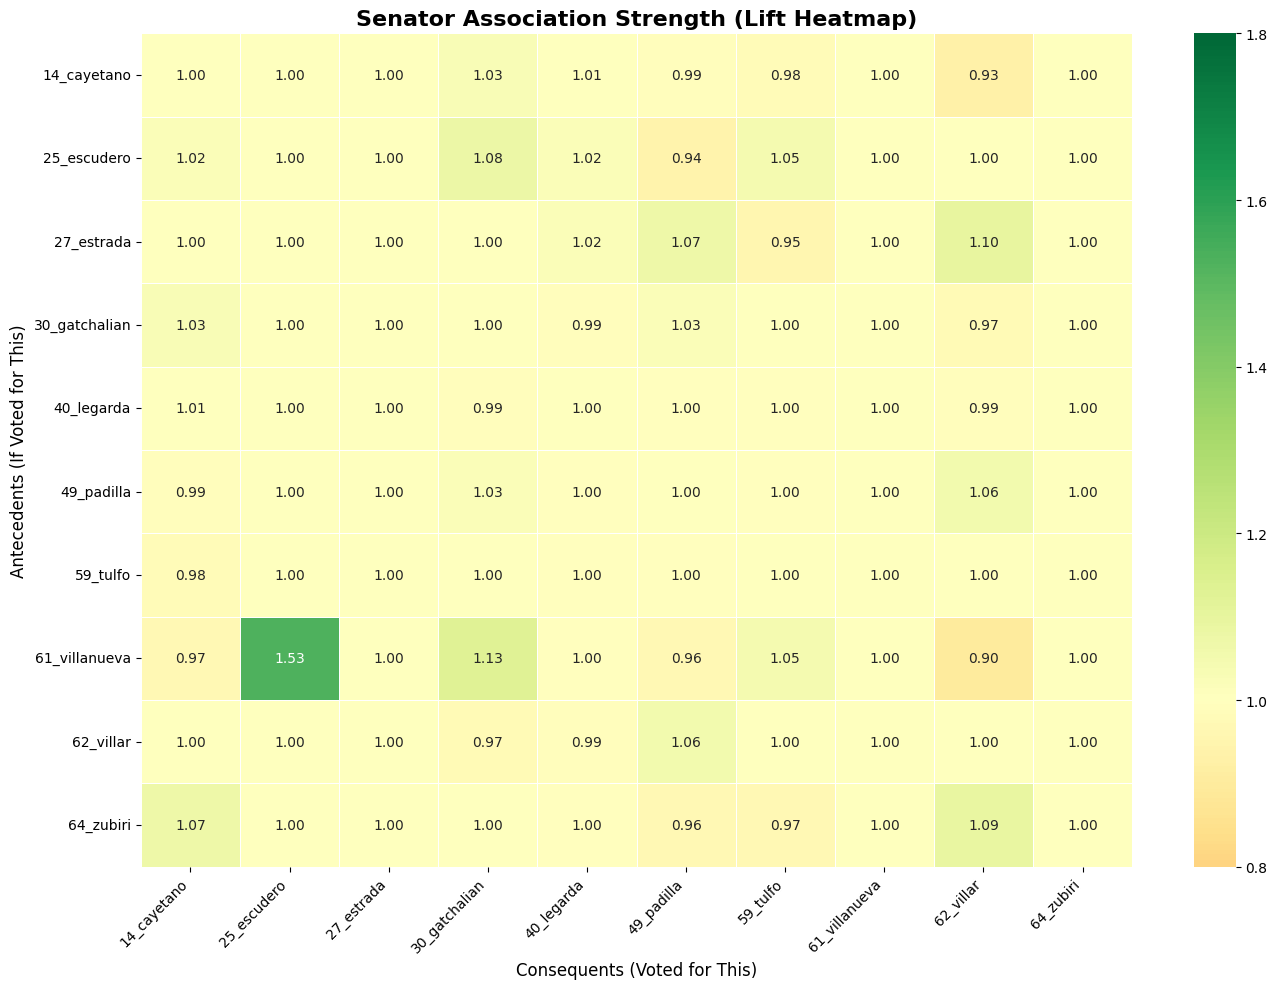

=== Step 4: Association Analysis ===

(a) Strongest positive association (lift >> 1):
    61_villanueva → 25_escudero | Lift: 1.5300
    Interpretation: When 61_villanueva votes YES, 25_escudero is 53.0% more likely to also vote YES than by chance.

(b) Weak/negative association (lift ≈ 1 or < 1):
    61_villanueva → 62_villar | Lift: 0.9000
    Interpretation: When 61_villanueva votes YES, 62_villar shows no meaningful association (lift near 1).


In [7]:
# Step 1: Filter rules to single antecedent → single consequent only
single_rules = rules[
    (rules['antecedents'].apply(lambda x: len(x) == 1)) &
    (rules['consequents'].apply(lambda x: len(x) == 1))
].copy()

single_rules['ant_name'] = single_rules['antecedents'].apply(lambda x: next(iter(x)))
single_rules['con_name'] = single_rules['consequents'].apply(lambda x: next(iter(x)))

# Step 2: Build a square lift matrix manually
senators = sorted(list(set(single_rules['ant_name']) | set(single_rules['con_name'])))

# Start with 1.0 as baseline
lift_matrix = pd.DataFrame(1.0, index=senators, columns=senators)

# Populate with actual lift values
for _, row in single_rules.iterrows():
    lift_matrix.loc[row['ant_name'], row['con_name']] = row['lift']

# Step 3: Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(lift_matrix,
            annot=True,
            cmap='RdYlGn',
            center=1.0,
            fmt=".2f",
            vmin=0.8,
            vmax=1.8,
            linewidths=0.5)

plt.title('Senator Association Strength (Lift Heatmap)', fontsize=16, fontweight='bold')
plt.xlabel('Consequents (Voted for This)', fontsize=12)
plt.ylabel('Antecedents (If Voted for This)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Step 4: Identify strongest and weakest associations
strongest = single_rules.loc[single_rules['lift'].idxmax()]
weakest   = single_rules.loc[single_rules['lift'].idxmin()]

print("=== Step 4: Association Analysis ===")
print(f"\n(a) Strongest positive association (lift >> 1):")
print(f"    {strongest['ant_name']} → {strongest['con_name']} | Lift: {strongest['lift']:.4f}")
print(f"    Interpretation: When {strongest['ant_name']} votes YES, {strongest['con_name']} is "
      f"{(strongest['lift']-1)*100:.1f}% more likely to also vote YES than by chance.")

print(f"\n(b) Weak/negative association (lift ≈ 1 or < 1):")
print(f"    {weakest['ant_name']} → {weakest['con_name']} | Lift: {weakest['lift']:.4f}")
print(f"    Interpretation: When {weakest['ant_name']} votes YES, {weakest['con_name']} shows "
      f"{'no meaningful' if abs(weakest['lift']-1) < 0.1 else 'weak'} association (lift near 1).")

# Task 5

In [8]:
top3 = single_rules.nlargest(3, 'lift')[['ant_name', 'con_name', 'support', 'confidence', 'lift']].reset_index(drop=True)

print("| Antecedent | Consequent | Support | Confidence | Lift |")
print("|------------|------------|---------|------------|------|")
for _, row in top3.iterrows():
    print(f"| {row['ant_name']} | {row['con_name']} | {row['support']:.4f} | {row['confidence']:.4f} | {row['lift']:.4f} |")

| Antecedent | Consequent | Support | Confidence | Lift |
|------------|------------|---------|------------|------|
| 61_villanueva | 25_escudero | 0.3778 | 0.8500 | 1.5300 |
| 61_villanueva | 30_gatchalian | 0.3889 | 0.8750 | 1.1250 |
| 27_estrada | 62_villar | 0.3222 | 0.8529 | 1.0966 |


### Interpretations

#### In 3–5 sentences, describe the voting bloc pattern you observe from the rules and heatmap. Do the associations align with the known political coalitions from 2022 (UniTeam vs. opposition)?
* The Uniteam members are Villar, Estrada and Gatchallian
* The rest being Villanueva and Escudero are not in the Uniteam which we can label as the opposition
* In the bloc pattern despite Villanueva not being a part of the Uniteam, It still became an Antecedent for Gatchallian, with a 0.3889 Support which is roughly 39%, this amount is considered as very high which basically means very common despite them being independent of each other, they also have high confidence of 0.8750 or 88% which is a high confidence meaning they are tightly linked, wherein if Villanueva was voted, Gatchallian is sure to follow, although when we look at the lift, they only have a 1.1250 score meaning they are technically only a common interest instead of actually being a tight bloc.
#### Name one limitation of using province-level aggregation for this MBA analysis. How might results differ if you used municipality-level transactions instead?
* The limitation of using province-level aggregation is it assumes that the result of a province basket as a whole rather than looking at the more specific ones like how municipality-level transactions do, if I were to use municipality-level transactions, it would increase the complexity of the analysis, some niche blocs would probably come out since we're looking at more specific parts of data and the lift value will increase since it will give sharper or more granular signals that will reveal the micro blocs in the data that have a higher mathematical lift because they are very different from the national average, therefore using provincial-level MBA analysis gives you the national story but municipality-level transactions give you the Regional Truths that the bigger picture ignore.

References
* Anthropic. (2025). Claude. Claude.ai. https://claude.ai/new
* Google. (2024). ‎Gemini. Gemini.google.com. https://gemini.google.com